# Day-Ahead 24-Hour Forecasting at 15-Minute Granularity (TFT)

This notebook performs **multi-step forecasting** for electricity price at **15-minute resolution**.

- Horizon: **24 hours = 96 steps**
- Uses past unknowns (price/demand) and known future covariates (weather + calendar).

## 1) Install dependencies (only if needed)
Run once if imports fail, then restart kernel.

In [1]:
%pip install -q pytorch-forecasting lightning

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")
pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision("medium")

c:\Users\rkale\miniconda3\envs\summer\lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


In [12]:
PROJECT_ROOT = Path.cwd().parent.parent.parent.parent
PRICE_PATH = PROJECT_ROOT / "data" / "price_data.csv"
WEATHER_PATH = PROJECT_ROOT / "data" / "historical_hourly_2025.csv"
OUTPUT_PATH = PROJECT_ROOT / "Prediction" / "tft_day_ahead_24h_15min.csv"

# 15-minute base series
price_df = pd.read_csv(PRICE_PATH)
ts_col = "timestamp" if "timestamp" in price_df.columns else "Timestamp"
price_df[ts_col] = pd.to_datetime(price_df[ts_col], utc=True, errors="coerce").dt.tz_convert(None)
price_df = price_df.rename(columns={ts_col: "Timestamp"})
price_df = price_df.sort_values("Timestamp").drop_duplicates("Timestamp")

base_cols = [c for c in ["Timestamp", "price", "demand_istdo", "demand_indo", "demand_indeem"] if c in price_df.columns]
price_df = price_df[base_cols]

full_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
price_df = price_df.set_index("Timestamp").reindex(full_index).rename_axis("Timestamp").reset_index()

# Hourly weather converted to smooth 15-minute weather by time interpolation
weather_df = pd.read_csv(WEATHER_PATH)
w_ts = "Timestamp" if "Timestamp" in weather_df.columns else "timestamp_utc"
weather_df[w_ts] = pd.to_datetime(weather_df[w_ts], utc=True, errors="coerce").dt.tz_convert(None)
weather_df = weather_df.rename(columns={w_ts: "WeatherTimestamp"}).sort_values("WeatherTimestamp")

hourly_keep = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "shortwave_radiation", "direct_radiation",
    "wind_speed_10m", "wind_gusts_10m", "wind_direction_10m",
    "surface_pressure", "weather_code"
]
hourly_keep = [c for c in hourly_keep if c in weather_df.columns]
weather_df = weather_df[["WeatherTimestamp"] + hourly_keep]

weather_df = weather_df.set_index("WeatherTimestamp")
weather_15min_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
weather_15min = weather_df.reindex(weather_15min_index)

numeric_weather_cols = [c for c in weather_15min.columns if c != "weather_code"]
if numeric_weather_cols:
    weather_15min[numeric_weather_cols] = weather_15min[numeric_weather_cols].interpolate(
        method="time", limit_direction="both"
    )

if "weather_code" in weather_15min.columns:
    weather_15min["weather_code"] = weather_15min["weather_code"].ffill().bfill()

weather_15min = weather_15min.reset_index().rename(columns={"index": "Timestamp"})
df = price_df.merge(weather_15min, on="Timestamp", how="left")

# Fill numeric gaps (demand / residual missing values)
for col in df.columns:
    if col == "Timestamp":
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].interpolate(limit_direction="both").ffill().bfill()

df = df.dropna(subset=["Timestamp", "price"]).sort_values("Timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Range: {df['Timestamp'].min()} -> {df['Timestamp'].max()}")
display(df.head(3))

Rows: 39,264
Range: 2025-01-01 00:00:00 -> 2026-02-13 23:45:00


,Timestamp,price,demand_istdo,demand_indo,demand_indeem,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,...,cloud_cover_low,cloud_cover_mid,cloud_cover_high,shortwave_radiation,direct_radiation,wind_speed_10m,wind_gusts_10m,wind_direction_10m,surface_pressure,weather_code
0,2025-01-01 00:00:00,9.07,26483.0,26395.0,-20467.0,6.4500,91.717640,5.20,1.30,1.30,...,62.0,100.0,100.0,0.0,0.0,19.941854,47.88,239.036320,980.603330,61.0
1,2025-01-01 00:15:00,9.07,26483.0,26395.0,-20467.0,6.4875,91.799757,5.25,1.35,1.35,...,67.5,100.0,100.0,0.0,0.0,19.727239,45.36,237.829975,980.410062,61.0
2,2025-01-01 00:30:00,23.51,26474.0,26395.0,-20467.0,6.5250,91.881875,5.30,1.40,1.40,...,73.0,100.0,100.0,0.0,0.0,19.512625,42.84,236.623630,980.216795,61.0


In [13]:
# 15-minute calendar features (known in the future)
df["hour"] = df["Timestamp"].dt.hour.astype(str)
df["quarter_hour"] = (df["Timestamp"].dt.minute // 15).astype(str)
df["quarter_of_day"] = ((df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute) // 15).astype(str)
df["day_of_week"] = df["Timestamp"].dt.dayofweek.astype(str)
df["is_weekend"] = (df["Timestamp"].dt.dayofweek >= 5).astype(str)

# Cyclical known reals
minute_of_day = df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute
df["tod_sin"] = np.sin(2 * np.pi * minute_of_day / 1440.0)
df["tod_cos"] = np.cos(2 * np.pi * minute_of_day / 1440.0)
df["dow_sin"] = np.sin(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)

# Time series ids
df["series_id"] = "GB"
df["time_idx"] = np.arange(len(df), dtype=np.int64)

MAX_PREDICTION_LENGTH = 96   # 24h * 4 steps/hour
MAX_ENCODER_LENGTH = 288     # 72h lookback at 15-min

known_weather = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "shortwave_radiation", "direct_radiation",
    "wind_speed_10m", "wind_gusts_10m", "wind_direction_10m",
    "surface_pressure"
]
known_reals = [c for c in known_weather if c in df.columns] + ["tod_sin", "tod_cos", "dow_sin", "dow_cos"]
known_categoricals = [
    c for c in ["hour", "quarter_hour", "quarter_of_day", "day_of_week", "is_weekend"] if c in df.columns
]
unknown_reals = [c for c in ["price", "demand_istdo", "demand_indo", "demand_indeem"] if c in df.columns]

test_steps = 7 * 24 * 4
val_steps = 7 * 24 * 4
train_cutoff = df.time_idx.max() - (val_steps + test_steps + MAX_PREDICTION_LENGTH)
val_start = train_cutoff + 1
test_start = df.time_idx.max() - (test_steps + MAX_PREDICTION_LENGTH) + 1

print("Known real covariates:", known_reals)
print("Known categorical covariates:", known_categoricals)
print("Unknown real covariates:", unknown_reals)
print(f"train_cutoff={train_cutoff}, val_start={val_start}, test_start={test_start}")

Known real covariates: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'wind_speed_10m', 'wind_gusts_10m', 'wind_direction_10m', 'surface_pressure', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos']
Known categorical covariates: ['hour', 'quarter_hour', 'quarter_of_day', 'day_of_week', 'is_weekend']
Unknown real covariates: ['price', 'demand_istdo', 'demand_indo', 'demand_indeem']
train_cutoff=37823, val_start=37824, test_start=38496


In [14]:
training = TimeSeriesDataSet(
    df[df.time_idx <= train_cutoff],
    time_idx="time_idx",
    target="price",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=known_categoricals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, min_prediction_idx=val_start, stop_randomization=True
)
test_set = TimeSeriesDataSet.from_dataset(
    training, df, min_prediction_idx=test_start, stop_randomization=True
)

batch_size = 256
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
test_loader = test_set.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"Train windows: {len(training):,} | Val windows: {len(validation):,} | Test windows: {len(test_set):,}")

Train windows: 37,441 | Val windows: 1,345 | Test windows: 673


In [ ]:
early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")

trainer = pl.Trainer(
    max_epochs=40,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    enable_checkpointing=False,
    logger=False
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4
)

print(f"Model params: {tft.size()/1e3:.1f}k")
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Model params: 175.1k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  2.3 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    896 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 63.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 51.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 175 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 175 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 920                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [ ]:
def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE(%)": mape}

raw_val, x_val, *_ = tft.predict(val_loader, mode="raw", return_x=True)
val_pred = raw_val["prediction"][:, :, 3].detach().cpu().numpy()
val_true = x_val["decoder_target"].detach().cpu().numpy()

raw_test, x_test, *_ = tft.predict(test_loader, mode="raw", return_x=True)
test_pred = raw_test["prediction"][:, :, 3].detach().cpu().numpy()
test_true = x_test["decoder_target"].detach().cpu().numpy()

print("Validation (96-step trajectories):")
for k, v in metrics(val_true, val_pred).items():
    print(f"  {k}: {v:.4f}")

print("\nTest (96-step trajectories):")
for k, v in metrics(test_true, test_pred).items():
    print(f"  {k}: {v:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

Validation (96-step trajectories):
  MAE: 8.9934
  RMSE: 11.9252
  MAPE(%): 10.8689

Test (96-step trajectories):
  MAE: 7.4436
  RMSE: 9.6132
  MAPE(%): 9.0696


In [ ]:
# Predict next 24h at 15-minute resolution (96 steps)
predict_ds = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
predict_loader = predict_ds.to_dataloader(train=False, batch_size=1, num_workers=0)
raw_next, _, *_ = tft.predict(predict_loader, mode="raw", return_x=True)

next_96_pred = raw_next["prediction"][0, :, 3].detach().cpu().numpy()
last_ts = df["Timestamp"].max()
future_ts = pd.date_range(last_ts + pd.Timedelta(minutes=15), periods=96, freq="15min")

forecast_df = pd.DataFrame({
    "Timestamp": future_ts,
    "predicted_price": next_96_pred
})

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
forecast_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
display(forecast_df.head())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Saved: C:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\Prediction\tft_day_ahead_24h_15min.csv


,Timestamp,predicted_price
0,2026-02-14 00:00:00,66.865227
1,2026-02-14 00:15:00,68.391083
2,2026-02-14 00:30:00,68.196007
3,2026-02-14 00:45:00,68.679893
4,2026-02-14 01:00:00,67.878067


Using quantiles -> low: 0.1, median: 0.5, high: 0.9


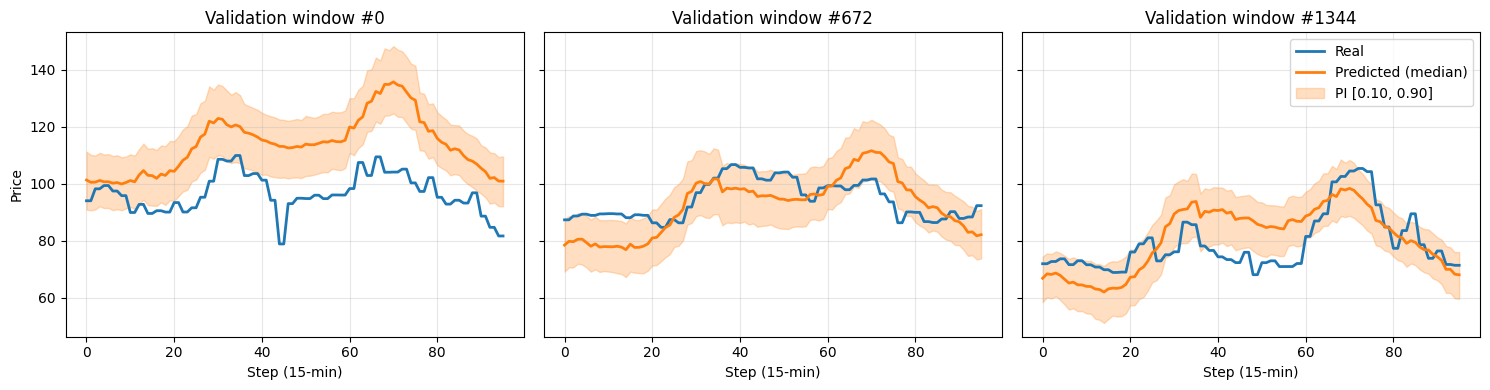

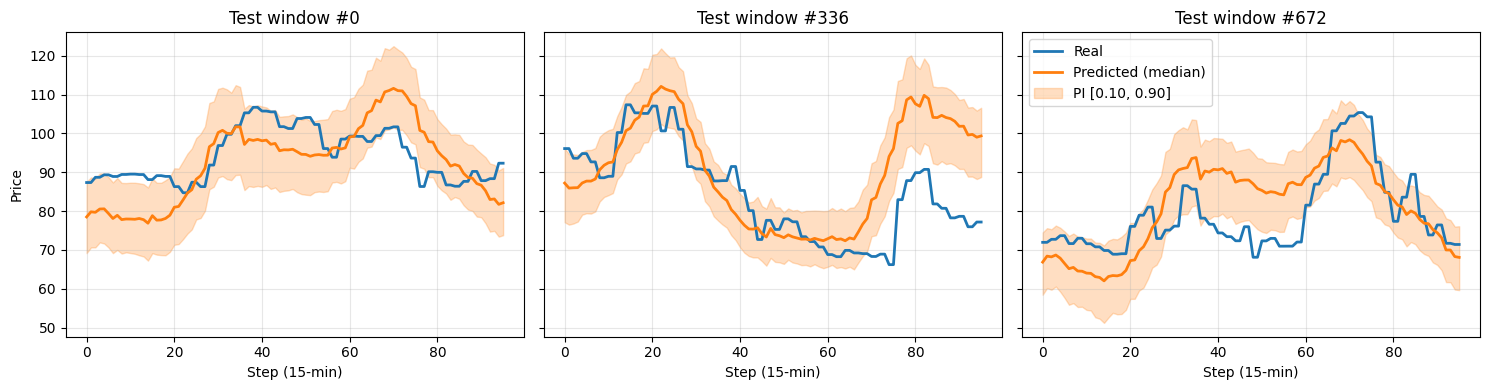

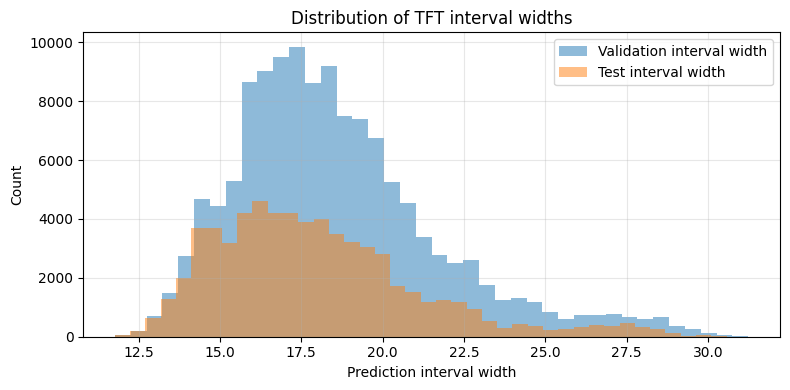

In [ ]:
# Real vs predicted with TFT prediction intervals (quantiles)

def select_window_indices(n_windows: int, n_show: int = 3) -> list[int]:
    if n_windows <= n_show:
        return list(range(n_windows))
    return np.linspace(0, n_windows - 1, n_show, dtype=int).tolist()

# TFT quantiles used by QuantileLoss (matches output_size)
quantiles = [float(q) for q in tft.loss.quantiles]
q_array = np.array(quantiles, dtype=float)

def q_idx(q: float) -> int:
    return int(np.argmin(np.abs(q_array - q)))

idx_q10 = q_idx(0.10)
idx_q50 = q_idx(0.50)
idx_q90 = q_idx(0.90)
print(f"Using quantiles -> low: {quantiles[idx_q10]}, median: {quantiles[idx_q50]}, high: {quantiles[idx_q90]}")

# Full quantile predictions for interval plotting
val_q = raw_val["prediction"].detach().cpu().numpy()  # [n_windows, horizon, n_quantiles]
test_q = raw_test["prediction"].detach().cpu().numpy()

def plot_windows_with_intervals(
    y_true: np.ndarray,
    y_quantiles: np.ndarray,
    title_prefix: str,
    n_show: int = 3,
    low_idx: int = idx_q10,
    med_idx: int = idx_q50,
    high_idx: int = idx_q90,
) -> None:
    idxs = select_window_indices(len(y_true), n_show=n_show)
    horizon = np.arange(y_true.shape[1])

    fig, axes = plt.subplots(1, len(idxs), figsize=(5 * len(idxs), 4), sharey=True)
    if len(idxs) == 1:
        axes = [axes]

    for ax, idx in zip(axes, idxs):
        y_low = y_quantiles[idx, :, low_idx]
        y_med = y_quantiles[idx, :, med_idx]
        y_high = y_quantiles[idx, :, high_idx]

        ax.plot(horizon, y_true[idx], label="Real", linewidth=2, color="#1f77b4")
        ax.plot(horizon, y_med, label="Predicted (median)", linewidth=2, color="#ff7f0e")
        ax.fill_between(
            horizon,
            y_low,
            y_high,
            alpha=0.25,
            color="#ff7f0e",
            label=f"PI [{quantiles[low_idx]:.2f}, {quantiles[high_idx]:.2f}]"
        )

        ax.set_title(f"{title_prefix} window #{idx}")
        ax.set_xlabel("Step (15-min)")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Price")
    axes[-1].legend(loc="best")
    plt.tight_layout()
    plt.show()

# Validation and test interval plots
plot_windows_with_intervals(val_true, val_q, "Validation", n_show=3)
plot_windows_with_intervals(test_true, test_q, "Test", n_show=3)

# Aggregate uncertainty width diagnostics
val_width = (val_q[:, :, idx_q90] - val_q[:, :, idx_q10]).reshape(-1)
test_width = (test_q[:, :, idx_q90] - test_q[:, :, idx_q10]).reshape(-1)

plt.figure(figsize=(8, 4))
plt.hist(val_width, bins=40, alpha=0.5, label="Validation interval width")
plt.hist(test_width, bins=40, alpha=0.5, label="Test interval width")
plt.xlabel("Prediction interval width")
plt.ylabel("Count")
plt.title("Distribution of TFT interval widths")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Production note
For true day-ahead use, replace decoder weather values with **forecast weather** for the next 96 time steps.